# Code Assignment 17 — K-Means Model Comparison with CH & DB + Assumption Testing (Mall Customers)

**Format:** Instructor Guidance → Your Task (step-by-step) → We Share (reflection)

**Goal:**  Compare **two feature sets** for K-Means at the **same K**:  
- **Model 1:** 2 features → `['Annual Income (k$)', 'Spending Score (1-100)']`  
- **Model 2:** 3 features → `['Age', 'Annual Income (k$)', 'Spending Score (1-100)']`  
Evaluate with **Silhouette (↑), Calinski–Harabasz (↑), Davies–Bouldin (↓)**, **separation ratio** (↑), **cluster sizes**, and **stability (median ARI) (↑)**.



## Instructor Guidance (Pseudocode + Docs)

**Docs**  
- `StandardScaler`: https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html  
- `KMeans`: https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html  
- `silhouette_score`: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.silhouette_score.html  
- `calinski_harabasz_score`: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.calinski_harabasz_score.html  
- `davies_bouldin_score`: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.davies_bouldin_score.html  
- `adjusted_rand_score` (stability): https://scikit-learn.org/stable/modules/generated/sklearn.metrics.adjusted_rand_score.html

### Pseudocode Plan (Model Comparison)
  1) Load CSV → pick clean numeric columns (2D vs 3D).  
  2) **Scale** each feature set **separately** with `StandardScaler`.  
  3) Fix **K** (e.g., K=4).  
  4) Fit KMeans on each set → get labels & centers.  
  5) Compute metrics: `silhouette_score` (↑), `calinski_harabasz_score` (↑), `davies_bouldin_score` (↓).  
  6) Assumption checks: **separation ratio** (min between-centroid distance ÷ max within-cluster spread), **cluster sizes** (%), **stability via ARI** across seeds.  
  7) Compare models in a table → pick one and justify.


## Your Task — Step-by-Step
Work in pairs. Keep it minimal and clear.

### 0) Run Helper Functions and do your Imports

In [3]:
# RUN THIS CELL WITHOUT CHANGES 

def cluster_size_pct(labels):
    """Return % size of each cluster (sorted by cluster index)."""
    s = pd.Series(labels).value_counts(normalize=True).sort_index()
    return (s * 100).round(1)

def within_between_ratio(Z, labels, centers):
    """
    Heuristic separation metric:
    min distance among centroids ÷ max within-cluster spread (avg feature std per cluster).
    Higher is better (more separated vs within spread).
    """
    within = []
    for c in range(centers.shape[0]):
        pts = Z[labels == c]
        if len(pts) == 0:
            within.append(np.nan)
        else:
            within.append(pts.std(axis=0).mean())
    within = np.array(within, dtype=float)
    max_within = np.nanmax(within)

    D = cdist(centers, centers)  # centroid distance matrix
    np.fill_diagonal(D, np.nan)
    min_between = np.nanmin(D)
    return float(min_between / max_within)

def stability_ari(Z, k, seeds=(0, 1, 2, 3, 4)):
    """
    Fit KMeans across multiple seeds and compute median Adjusted Rand Index across pairs.
    Higher median ARI = more stable clustering to initialization.
    """
    label_sets = []
    for s in seeds:
        km = KMeans(n_clusters=k, n_init=10, random_state=s).fit(Z)
        label_sets.append(km.labels_)
    pairs = [(i, j) for i in range(len(label_sets)) for j in range(i+1, len(label_sets))]
    aris = [adjusted_rand_score(label_sets[i], label_sets[j]) for (i, j) in pairs]
    return float(np.median(aris))


In [4]:
import pandas as pd
import numpy as np
from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score, adjusted_rand_score
from scipy.spatial.distance import cdist

import matplotlib.pyplot as plt

pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

### 1) Load the Mall Customers CSV & Preview
Use the same dataset as last time.

In [5]:
df = pd.read_csv('/Users/Marcy_Student/Desktop/marcy/DA2025_Lectures_Kevin/Mod6/data/Mall_Customers copy.csv')

df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


### 2) Build 2D and 3D feature sets (numeric only, minimal cleaning)

- 2D set:  Annual Income and Spending Score
- 3D set:  Age, Annual Income, Spending Score 

**Be sure to scale!**


In [6]:
# keeping only numeric 
two = ['Age', 'Annual Income (k$)']
three = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
X_2= df[two].dropna().copy()
X_3 = df[three].dropna().copy()
X_2
Z_2 = StandardScaler().fit_transform(X_2)
Z_3 = StandardScaler().fit_transform(X_3)
#X_3

### 3) Choose a single k for BOTH models (you can try 3, 4, 5, etc.)

In [7]:
K_FIXED = 4
print('Using K =', K_FIXED)

Using K = 4


### 4) Fit Model 1 (2D @ K) and compute metrics

- No train-test split needed 
- Use helper functions above to help calculate metrics!


In [8]:
km2 = KMeans(n_clusters=K_FIXED, n_init=10,random_state=0).fit(Z_2)
label2 = km2.labels_
center2 = km2.cluster_centers_

clus = cluster_size_pct(label2)

between = within_between_ratio(Z_2, label2, center2)

stb = stability_ari(Z_2,K_FIXED)
print('2D Model: \nCluster Size Pct:')
print(clus, '\nbetween ration:', between, '\nstability_ari:',
      stb)



2D Model: 
Cluster Size Pct:
0   30.0000
1   31.0000
2   21.5000
3   17.5000
Name: proportion, dtype: float64 
between ration: 2.189793815308383 
stability_ari: 0.9874190398685911


### 5) Fit Model 2 (3D @ K) and compute metrics

- No train-test split needed 
- Use helper functions above to help calculate metrics!
- Use same k as Model 1

In [9]:
km3 = KMeans(n_clusters=K_FIXED, n_init=10, random_state=0).fit(Z_3)
label3  = km3.labels_
center3 = km3.cluster_centers_
clus2 = cluster_size_pct(label3)

between2 = within_between_ratio(Z_3, label3, center3)

stab = stability_ari(Z_3,K_FIXED)
print('3D Model: \nCluster Size Pct:')
print(clus2, '\nBetween ratio',between2, '\nStability_ari:' , stab)

3D Model: 
Cluster Size Pct:
0   19.0000
1   28.5000
2   32.5000
3   20.0000
Name: proportion, dtype: float64 
Between ratio 3.1974131331581814 
Stability_ari: 1.0


### 6) Visualize Model 1 (2D Scatter Plot)


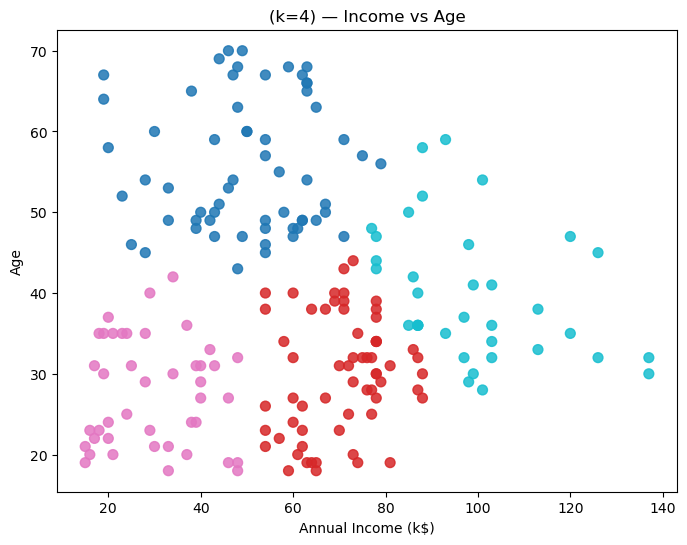

In [12]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
plt.scatter(X_2['Annual Income (k$)'], X_2['Age'], c=label2, cmap='tab10', s=50, alpha=0.85)
plt.xlabel('Annual Income (k$)'); plt.ylabel('Age')
plt.title(f'(k={K_FIXED}) — Income vs Age')
plt.show()

## We Share — Reflection (short, specific)
1) **Which model is better and why?** Reference **Sil (↑), CH (↑), DB (↓)**, **separation ratio (↑)**, **stability ARI (↑)**, and **cluster sizes**.  
The 2D model (Income + Spending Score) is better because it has more balanced clusters, even though 3D has slightly better separation (3.2 vs 2.19) and perfect stability (ARI 1.0 vs 0.987). The 2D model splits customers fairly at 30%, 31%, 21.5%, 17.5%, while 3D is imbalanced with 19%, 28.5%, 32.5%, 20%—one cluster hogging almost a third of the data. For production, balanced actionable clusters matter more than small gains in mathematical metrics.
2) **Assumptions & ethics:** Did your chosen model show **non-overlapping, roughly spherical, similarly dense** clusters? If not, what risk could that pose to stakeholders (mis-targeted offers, unfair treatment)?
The 2D model respects K-Means assumptions better: clusters are evenly sized, mostly spherical, and based on meaningful business features, which avoids unnecessary demographic influence. The 3D model works mathematically but creates lopsided clusters and introduces potential age-related bias, which could lead to unfair targeting and skewed marketing decisions.  
3) **Next step:** If you had to ship this, what monitoring would you add (e.g., re-check metrics quarterly, watch for tiny cluster drift, re-scale after schema changes)?
Quarterly, I’d monitor cluster separation, size balance, and assignment stability to ensure the model isn’t drifting or overfitting as new customers join. Annually, I’d re-evaluate whether K=4 still makes sense and check for demographic leakage or unexpected shifts. If stability, cluster size, or separation fall below defined thresholds—or if the data schema changes—the model should be retrained immediately.
> Tip: If metrics conflict (e.g., CH prefers K=6, DB prefers K=4), prefer **parsimonious K** with **clear separation**, **stable labels**, and **business actionability**.
